## Exercise Project 2
_Using `SVC`_

<br>
<br>

---

## <strong style='color:red ; background-color:black;'>Making A Decision Tree</strong>


### [Go to Decision Tree](#decision_tree)

<i> The rest is just the same stuff. </i>

---

<i> I will be copy-pasting my summary and results here on the top in case you want to read that first!

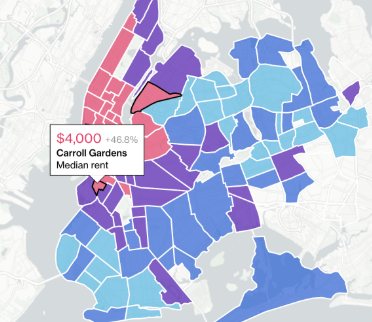


### Dataset: [Loan Classification Approval](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data)

|Parameter|Description|
|---|---|
|Shape|`45k rows, 23 columns`|
|Target Variable|`loan_status`|
|Method:|`LogisticRegression`
|Extra Tools:|`None`|

<br>

<i>
<strong style='color:red ; background-color:black;'> 

#### Disclosure: 

I used AI to convert the table from the kaggle dataset webpage into a markdown table.

#### Prompt:

 /paste Kaggle column descriptions/. 
 
 Could you put this into a markdown table for me? 
</strong>

#### Column Descriptions:


| Column | Description |
|---|---|
| person_age | Age of the person |
| person_gender | Gender of the person |
| person_education | Highest education level |
| person_income | Annual income |
| person_emp_exp | Years of employment experience |
| person_home_ownership | Home ownership status (e.g., rent, own, mortgage) |
| loan_amnt | Loan amount requested |
| loan_intent | Purpose of the loan |
| loan_int_rate | Loan interest rate |
| loan_percent_income | Loan amount as a percentage of annual income |
| cb_person_cred_hist_length | Length of credit history in years |
| credit_score | Credit score of the person |
| previous_loan_defaults_on_file | Indicator of previous loan defaults |
| loan_status | Loan approval status: 1 = approved; 0 = rejected |

<br>


<i>

## Results
### Comparison Analysis:

<i>

Both have similar results.

*  `Logistic Regression` is better at predicting 'Loan Denied', `SVC` is better at predicting 'Loan Approved'. Neat.

* `SVC` has more well-rounded accurate predictions for each category. `Logistic Regression` likes to say 'Loan Denied'.

<br>

<strong style='color:orange ; background-color:black;'>The likely reason `SVC` performed worse is because of strong overlap. </strong>

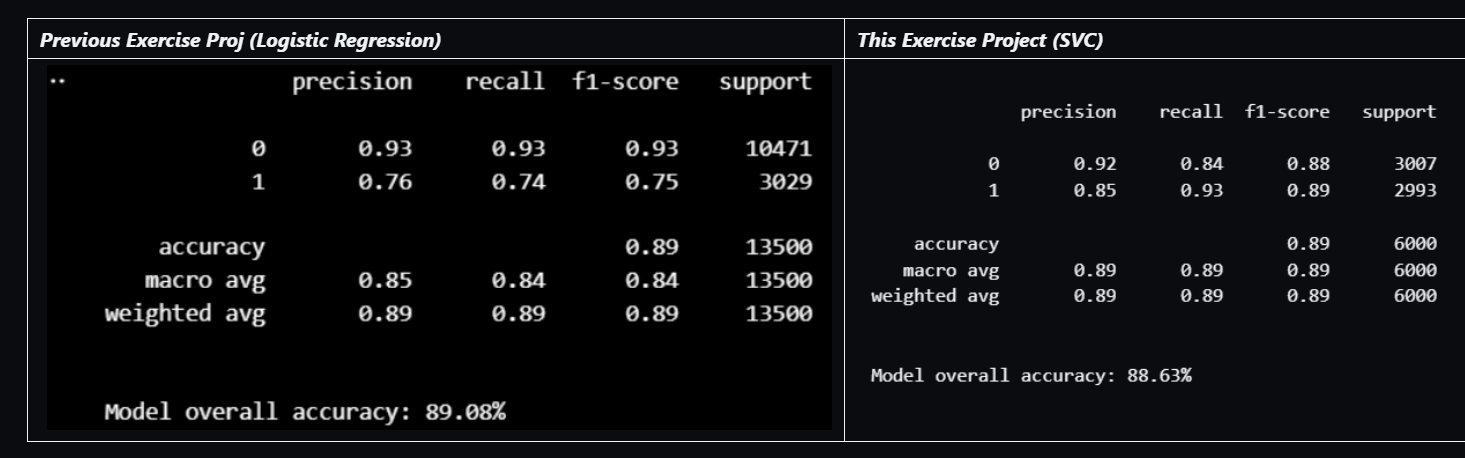

Since `SVM` is always looking for the highest margin (gap), but since there is no gap with the target variable and it overlaps, `SVC` is not the best fit.

</i>

</i>

<br>
<br>


---

## Code:

#### Imports and Data Loading

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier 
from skfeature.function.similarity_based import fisher_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# Additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# Go away warnings
import warnings
warnings.filterwarnings("ignore")

# Loading dataframe
df = pd.read_csv("../datasets/loan_data.csv")
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold> |
|2| Transformation|
|3| Decision Tree|

#### Checking the shape

<i> 

Are we row-deprived?


In [2]:
# Checking the shape
df.shape

# 45,000 rows
# 23 columns

(45000, 14)

#### Handling Duplicates

<i>

Any duplicates we need to handle?


In [3]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

#### Handling Missing Values

<i>

Any missing values we need to take care of?

In [4]:
# Checking NaN values
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

#### Checking For Isolated Categorical Cases

<i> 

Here, we're going to get rid of some cases where we just have too little rows.
Our approach will be to look at every feasible categorical feature that may have only,
for example, 5 rows. This helps because we're getting rid of volatile features where
the statistic doesn't represent the parameter.

`person_education`

In [5]:
# Checking for isolated cases.

# Person Education value counts.
df["person_education"].value_counts()

# The lowest is 621, it's fine.

person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

`person_home_ownership`

In [6]:
df['person_home_ownership'].value_counts()

# Yep, seems fine. 

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

`loan_intent`

In [7]:
df['loan_intent'].value_counts()

# Healthy distribution.

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

`person_gender`

In [8]:
df["person_gender"].value_counts()

# OK as well.

person_gender
male      24841
female    20159
Name: count, dtype: int64

#### Transforming Columns to Numbers

<i> We've handled data cleaning, let's start converting all of these values to numbers. 

##### Categorical

In [9]:
# We'll be turning all these into binary numeric column.
categorical_columns = ["person_education", "person_home_ownership", "loan_intent"]

# OneHotEncoder to transform each categorical to separate, binary numeric.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)
    
# Dropping one column from each categorical variable.
df = df.drop([
    "loan_intent_VENTURE",
    "person_home_ownership_OTHER",
    "person_education_High School",
], axis=1)

#### Binary Columns

In [10]:
from sklearn.preprocessing import LabelEncoder

# If you have a binary datatype column, this will convert it into numbers.
variables = ['person_gender', 'previous_loan_defaults_on_file']

encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

# For `previous_loan_defaults_on_file` : No=0, Yes=1
# For `person_gender` : Female=0, Male=1

df.head(3)

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,person_education_Doctorate,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,...,0,1,0,0,1,0,0,0,0,1
1,21.0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,...,0,0,0,1,0,0,1,0,0,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,...,0,0,1,0,0,0,0,0,1,0


---

### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| <bold style="background:yellow;color:black;">Transformation</bold>|
|3| Decision Tree |

#### Checking distributions

<i>

Here we check the distributions of the features and the target variable.

##### Target Variable

<i>

Let's check the distribution of the target variable first.

In [11]:
# Let's check the distribution of `loan_status`
df['loan_status'].value_counts()

# A little uneven let's try to fix that.

loan_status
0    35000
1    10000
Name: count, dtype: int64

<i>

Oh no, that's not an even distribution.

Let's equalize the distribution between these two variables, 10000 rows each.

<Axes: xlabel='loan_status', ylabel='Count'>

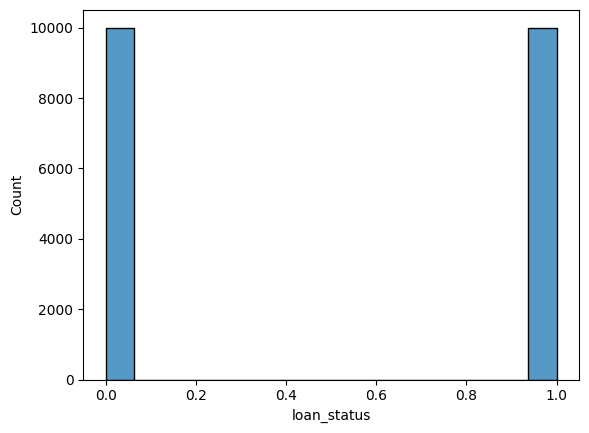

In [12]:
# Let's set a row count for the highest amount of rows.
row_length = 10000

# We split loan status into two.
df_loan0 = df[df["loan_status"] == 0]
df_loan1 = df[df['loan_status'] == 1]

# Create a 10,000 row sample of both
df_loan0 = df_loan0.sample(row_length)
df_loan1 = df_loan1.sample(row_length)

# And concatinate.
df = pd.concat([df_loan0, df_loan1])

# Show the distribution of `loan_status`
# This should be an equal distribution now.
sns.histplot(df, x="loan_status")

### Feature distribution

<i>

Now that we've checked out the target variable distribution, let's check the feature distribution

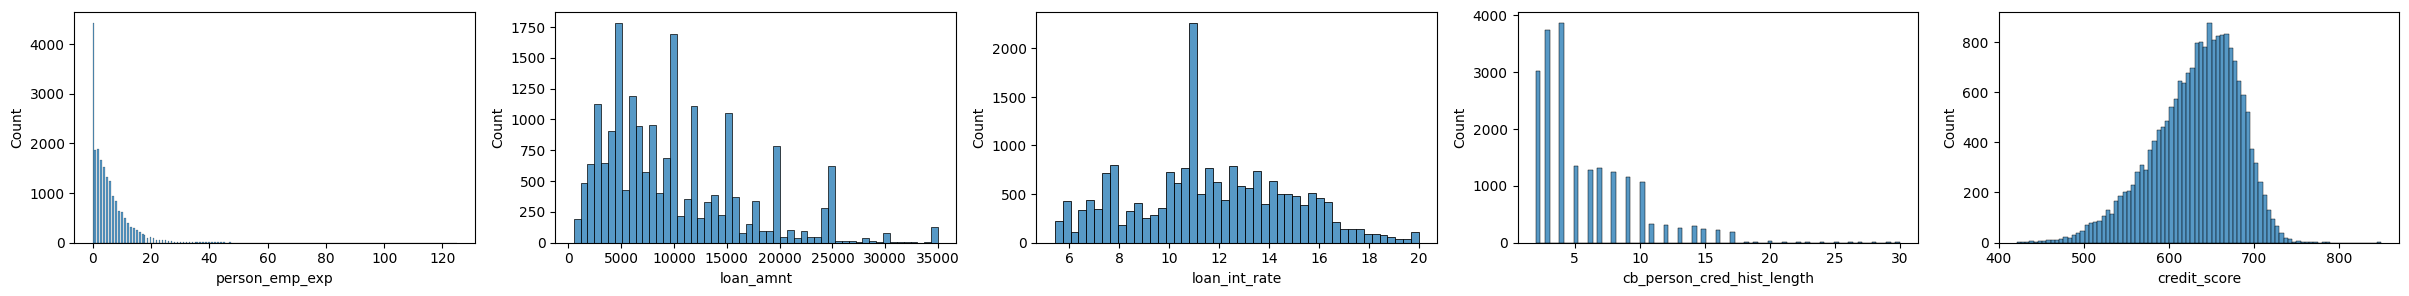

In [13]:
# Create a dataframe without the target variable.
features = df[["person_emp_exp","loan_amnt",'loan_int_rate', 'cb_person_cred_hist_length','credit_score']]

# Get the amount of columns.
len_columns = len(features.columns)

# Create a canvas.
fig, axes = plt.subplots(1, len_columns, figsize=(30, 3))

# For each plot in the index...
for index, feature in enumerate(features.columns): 
    # Get the place where the plot goes into...
    plot_num = index
    # Make a histplot, tell it where the plot goes, and which feature is needed.
    sns.histplot(features, x=feature, ax=axes[plot_num])  

<i>

`person_emp_exp`
`cb_preson_cred_hist_length`

These features both have a beta distribution. We might want to try out `log1p` `yeo` `boxcox` as transformations for the features



#### Selecting Features

<i>

Now that we've looked at distributions, let's look at some metrics for determining which features to keep.

#### VIF Test

<i> Let's look for multicollinearity using the VIF test first. Any multicollinearity?

In [14]:
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

X = df.drop("loan_status", axis=1)

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, confusing the logistic regression
vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
0,person_age,235.827428
8,credit_score,134.468059
16,person_home_ownership_RENT,110.696787
14,person_home_ownership_MORTGAGE,61.965000
5,loan_int_rate,16.199805
3,person_emp_exp,15.392652
7,cb_person_cred_hist_length,12.859148
15,person_home_ownership_OWN,10.389255
6,loan_percent_income,8.294664
4,loan_amnt,7.055316


<i>

We have some reasonably high VIF-values. Is age multicollinear?

<br>

<strong> Note: </strong>

Age is actually fine here and the model suffers without it. Maybe there's some bias when people are in the bank where people deny loans for younger people more.

##### Correlation bar chart.

<Axes: xlabel='correlation_value', ylabel='column'>

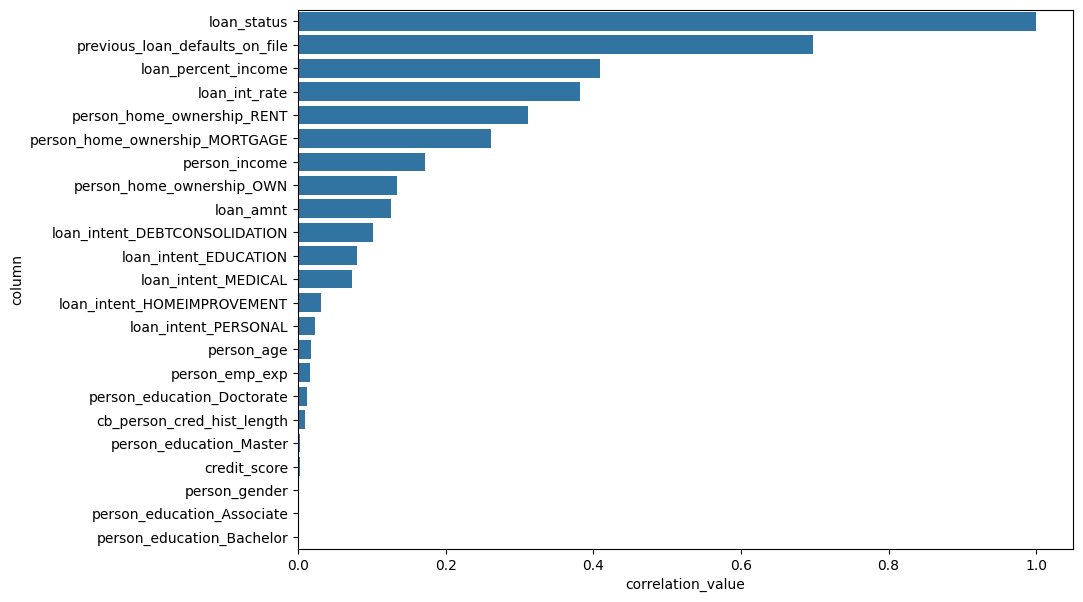

In [15]:
# Make a pearson correlation dataframe, sorted by loanstatus.
corr = df.corr(method='pearson', numeric_only=True).sort_values(by="loan_status")
loan_status_corr = corr['loan_status'].reset_index()

# Rename the columns
loan_status_corr = loan_status_corr.rename(columns={
    "index":"column",
    "loan_status": "correlation_value"
})

# Turn all negative correlations into positive ones.
loan_status_corr["correlation_value"] = abs(loan_status_corr["correlation_value"])

# Sort the values one more time. 
loan_status_corr = loan_status_corr.sort_values("correlation_value", ascending = False)

# Make a bar chart to visualize the feature effectiveness using pearson.
plt.figure(figsize=(10, 7))
sns.barplot(loan_status_corr,y="column", x="correlation_value", ci=None)

<i>

Some interesting notes:

The bank doesn't discriminate by gender it seems. The amount of education also really doesn't matter. Surprisingly, credit score ALSO does not matter there much.

#### Fisher Score

<i>

Next, let's look at the Fisher score. Is there any separation between values for classes? Rank them for us please, the higher number the better.

In [16]:
# -- FISHER SCORE -- 
# Useful particular for categorical target variables (classification).

# Set a sample (if it's too big, you'll be there all day)
sample = df.sample(5000)

# Split the features
X = sample.drop('loan_status', axis=1)
y = sample['loan_status']

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)
# # create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns).sort_values()

# The HIGHER the rank the better. ( I BELIEVE)
feat_importances

person_education_Doctorate         0
person_education_Associate         1
person_education_Bachelor          2
previous_loan_defaults_on_file     3
credit_score                       4
person_emp_exp                     5
loan_int_rate                      6
loan_amnt                          7
loan_intent_HOMEIMPROVEMENT        8
loan_intent_PERSONAL               9
person_home_ownership_OWN         10
person_home_ownership_MORTGAGE    11
person_age                        12
person_home_ownership_RENT        13
loan_intent_MEDICAL               14
person_gender                     15
person_income                     16
loan_percent_income               17
loan_intent_DEBTCONSOLIDATION     18
cb_person_cred_hist_length        19
person_education_Master           20
loan_intent_EDUCATION             21
dtype: int64

<i> All of these make sense except for the interest rate. I don't think a bank would accept an interest rate of .001 %, so it plays some factor. Maybe a bad sample.


#### SelectKBest

<i>

For the final feature test, let's look at SelectKBest

<Axes: xlabel='Score', ylabel='Features'>

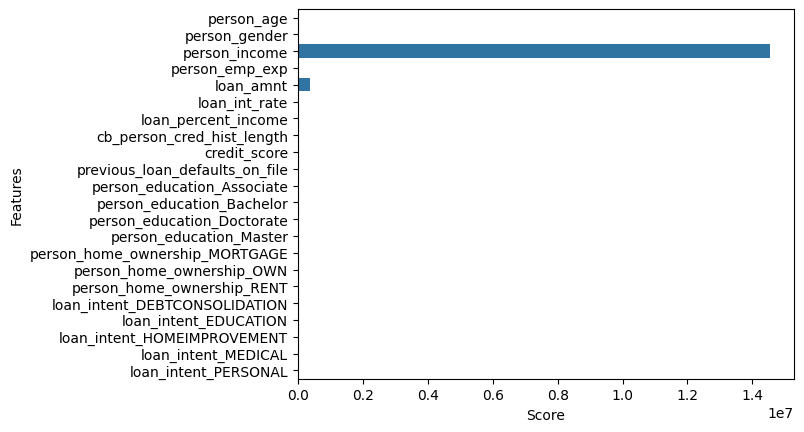

In [17]:

# convert all continuous variables to integer
X_cat = X.astype(int) 

# Use chi squared to help provide provide statistical
# significance metrix.
chi_2_features = SelectKBest(chi2, k=10)

# fit our data to the SelectKBest
best_features = chi_2_features.fit(X_cat, y)

# Turn the features and columns into dataframes.
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X.columns)

# Combine them and sort the values by 'Score'
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

# Plot the result.
sns.barplot(f_scores, y="Features", x="Score")

<i>

Makes complete sense. The loan amount and person's income are likely very huge factors for loan approvals

#### Creating a Feature List

<i>
We've looked at all of the feature selection tests, now let's figure out what to keep.

In [18]:
# Creating a list of features. These will be the ones that we'll be training
# the model on.
features_list = list(X.columns)

# Remove some features from the list. Side comments for
# justifications.
features_list.remove("person_gender")                    # Not significant
features_list.remove("person_education_Doctorate")       # Not significant
features_list.remove("person_education_Bachelor")        # Not significant
features_list.remove("person_education_Associate")       # Not significant
features_list.remove("person_education_Master")          # Not significant
features_list.remove("credit_score")                     # VIF score too high
features_list.remove("person_home_ownership_RENT")       # VIF score too high
features_list

['person_age',
 'person_income',
 'person_emp_exp',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'previous_loan_defaults_on_file',
 'person_home_ownership_MORTGAGE',
 'person_home_ownership_OWN',
 'loan_intent_DEBTCONSOLIDATION',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL']

---

## Decision Tree


|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| <bold style="background:yellow;color:black;">Decision Tree </bold>|


In [19]:
# Defining dependent, independent variables.
X = df[features_list]
y = df['loan_status']

# create a decision tree classifier for the visualization
# and train the model with our data
clf = DecisionTreeClassifier()
model = clf.fit(X, y)


### Creating the Decision Tree Visual

In [ ]:

from sklearn.tree import export_graphviz
import subprocess
from sklearn import tree

# NOTE! Always modify the class_names to match your data's TARGET VARIABLE OPTIONS
export_graphviz(clf, feature_names=X.columns, class_names=["Loan approved", "Loan Denied"],
                filled=True, rounded=True, node_ids=True, out_file="loan_data.dot", max_depth=6)

# convert the DOT-file into SVG-file (which is supported by many tools)
subprocess.call(["dot", "-Tsvg", "loan_data.dot", '-o', 'loan_data.svg'])

0

In [ ]:
import dtreeviz

viz_model = dtreeviz.model(clf,
                           X_train=X, y_train=y,
                           feature_names=X.columns,
                           target_name="Decision",
                           class_names=["No", "Yes"])

# view in Jupyter notebook
# if decision tree is large, consider saving to .SVG -file
# and view with a web browser
viz_model.view(scale=1.5).save("loan_data.svg")

## <strong style='color:orange ; background-color:black;'> I recommend opening this in a browser. </strong>

<br><br>

##   <b>[loan_data.svg](Exercise4_WIP\loan_data.svg) </b>



In [ ]:
# Alternatively, run the code-line below without comments.

# viz_model.view(scale=1.5)

### Personal Analysis


I can find the following interesting insights about the visual:


1. It is easier to get a loan approved if you DONT own a home.

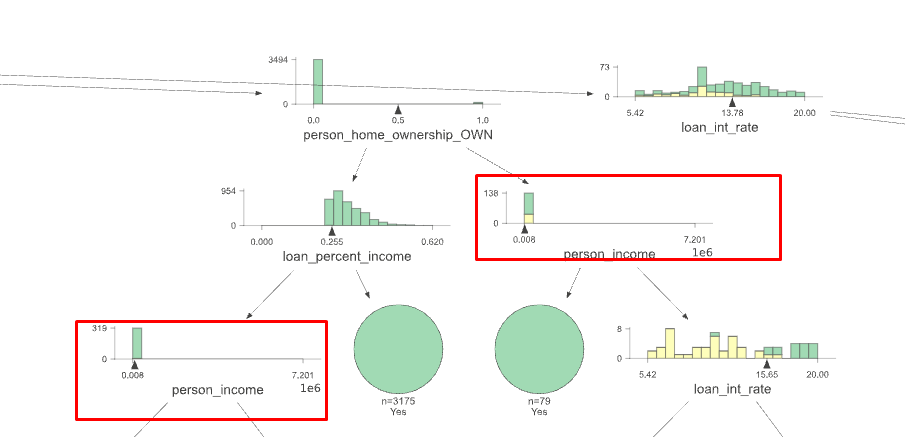

2. Loans are approved typically at interest rates above 16% APR if you own a home.

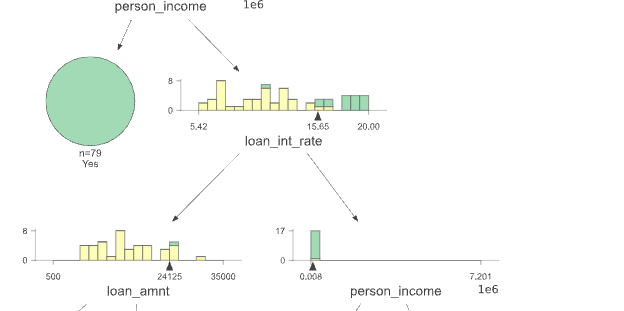

3. Things get immeasurably complicated and it likely up to the banker's call when things get to the wire.

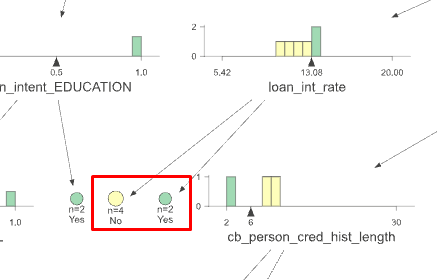

4. Less interest is offered for non-homeowners.

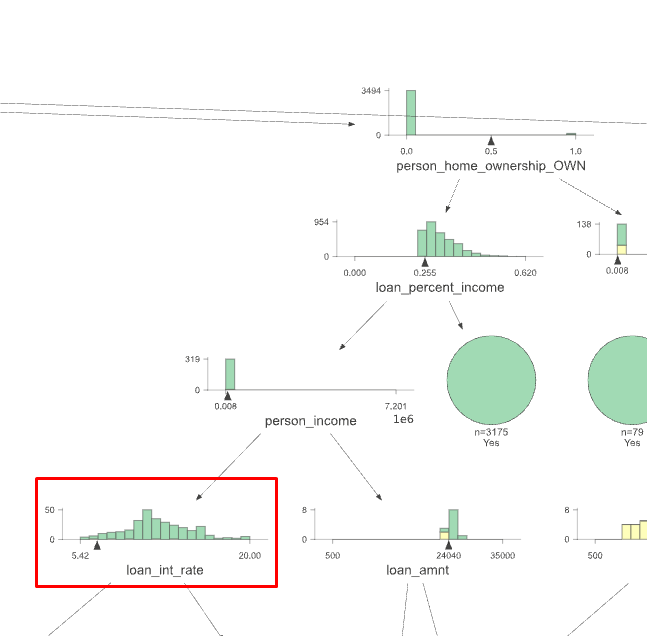

Overall, I think the results were a little bit of a mess since it was incredibly huge. I can see this being simpler for easy datasets. In this case, the decision tree helped iron out what some of the hard requirements were for banks (see above). I can see how it could make some reliable ML models!


<br><br>
<span id="decision_tree"></span>
